In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("titanic.csv")

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.shape

(891, 12)

In [11]:
df.size

10692

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
from sklearn.impute import SimpleImputer

In [14]:
si=SimpleImputer(strategy="mean")
df[["Age"]]=si.fit_transform(df[["Age"]])

In [15]:
si=SimpleImputer(strategy="most_frequent")
df[["Cabin"]]=si.fit_transform(df[["Cabin"]])
df[["Embarked"]]=si.fit_transform(df[["Embarked"]])

In [16]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [17]:
l_cols=["Name","Sex","Cabin","Embarked","Ticket"]

In [18]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for j in l_cols:
    df[j]=le.fit_transform(df[j])

In [19]:
cols=df.columns.tolist()

In [20]:
import math
n=len(cols)
rows=math.ceil(n/2)

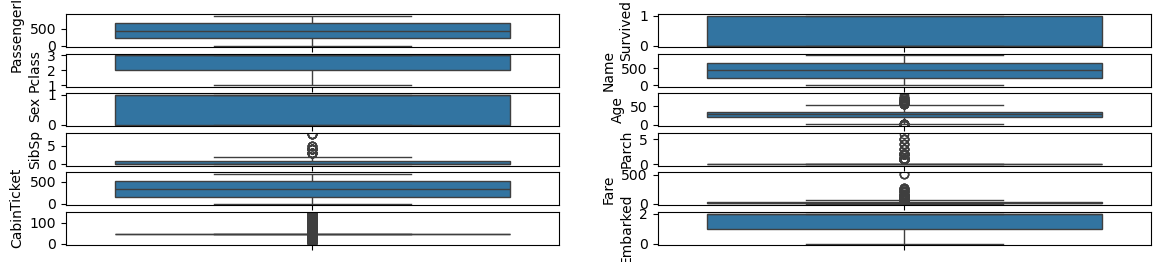

In [21]:
plt.figure(figsize=(14,3))
for i in range (len(cols)):
    plt.subplot(rows,2,i+1)
    sns.boxplot(df[cols[i]])

In [22]:
cols1=["Age","Parch","Fare","Cabin","SibSp"]

In [26]:
from scipy.stats.mstats import winsorize
for cols1 in cols:
    df[cols1]=winsorize(df[cols1],limits=(0.01,0.01))

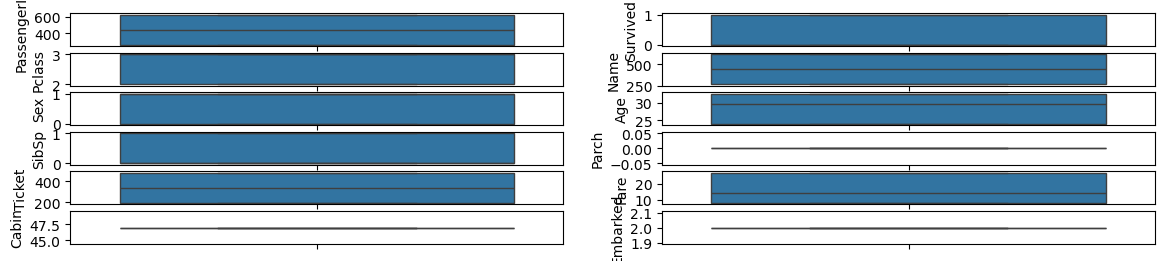

In [27]:
plt.figure(figsize=(14,3))
for i in range (len(cols)):
    plt.subplot(rows,2,i+1)
    sns.boxplot(df[cols[i]])

In [28]:
from sklearn.preprocessing import StandardScaler
s_cols=["PassengerId","Pclass","SibSp","Parch","Fare",]

In [29]:
ss=StandardScaler()
for k in s_cols:
    df[[k]]=ss.fit_transform(df[[k]])

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report

In [31]:
X=df[["Pclass","Sex","Age"]]
y=df["Survived"]

In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
kn=KNeighborsClassifier(n_neighbors=9)

In [34]:
kn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=9)

In [35]:
y_pred=kn.predict(X_test)


In [36]:
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.8044692737430168


In [40]:
cm=confusion_matrix(y_test,y_pred)

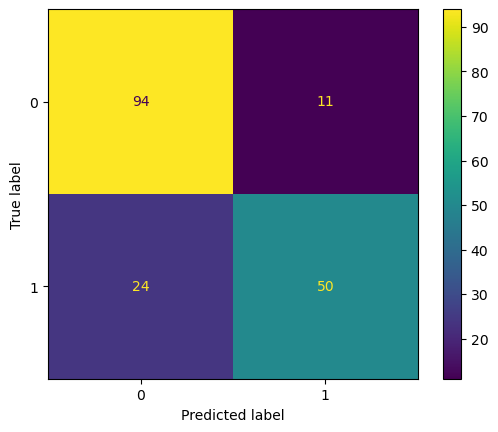

In [45]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

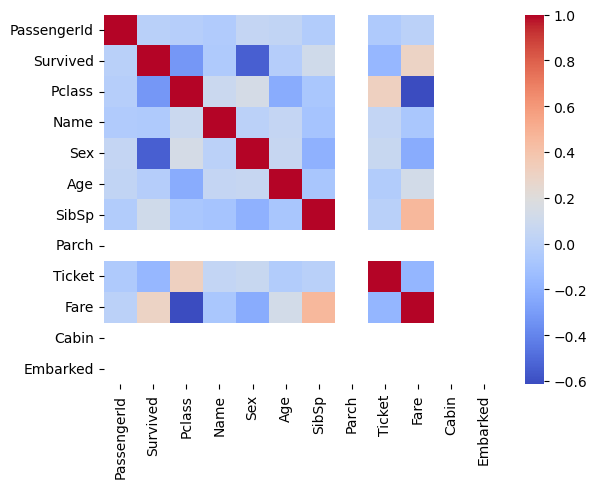

In [42]:
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

In [43]:
print("Classification_report:",classification_report(y_test,y_pred))

Classification_report:               precision    recall  f1-score   support

           0       0.80      0.90      0.84       105
           1       0.82      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.80      0.80       179



In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

X_vis = StandardScaler().fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_vis, y)

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3)

sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=y, palette="Set1")

plt.show()

ValueError: X has 2 features, but KNeighborsClassifier is expecting 3 features as input.